# Estimate agricultural land fraction (exposure)

**Do you want to estimate the fraction of agricultural land for your region?**

This short how-to gives you the code you need to create a timeseries of the agricultural land fraction using satellite-based land cover data and save it as a csv file. The final csv file can be used as, e.g., exposure data for the drought risk estimation. 

**Do uou want to see this data in action?** 
We use it in the "quick start" guide as exposure! Take a look 

## Set region and load libraries

In [82]:
import cdsapi 
import zipfile
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
import os
from pathlib import Path

# Create a data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

In [81]:
# Create regions subdirectory
regions_dir = data_dir / 'regions'
regions_dir.mkdir(exist_ok=True)

# Read NUTS shapefiles
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

DataSourceError: data/regions/NUTS_RG_20M_2024_4326/NUTS_RG_20M_2024_4326.shp: No such file or directory

In [4]:
admin_id = "EL64"
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Found {admin_id} region: {sel_gdf.geometry.total_bounds}")

Found EL64 region: [21.39637798 37.98898161 24.67199242 39.27219519]


In [5]:
# Define bounding box for admin region 
# Format: [North, West, South, East]
lon_min, lon_max = sel_gdf.geometry.total_bounds[0], sel_gdf.geometry.total_bounds[2]
lat_min, lat_max = sel_gdf.geometry.total_bounds[1], sel_gdf.geometry.total_bounds[3]


## Download Land Cover Data

We'll use a high-resolution land cover dataset to identify agricultural areas within your region, and create a timeseries of the fraction of agricultural land. 

The dataset that we are using here is from Copernicus, and is entitled "Land cover classification gridded maps from 1992 to present derived from satellite observations". The dataset is at 300m spatial resolution. You can find more details here: https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview

It contains two versions: version 2.0.7cds provides the land cover for the years 1992 – 2015; and version 2.1.1 for the years after 2016. We'll download both versions to create a timeseries. Due to the volume of the dataset, we'll download year by year. 

> ⏱️ **Time needed!** Requesting and downloading this high-resolution data for just one year, even if cut down to the region of interest, takes about ~9 minutes. For all years currently available (1992-2023), the download takes about **4 hours**. 


In [11]:
for yyyy in range(1992, 2023):
    print(f"Year {yyyy}: Downloading land cover data...")

    # check if file already exists
    if (data_dir / f'land_cover_{admin_id}_{yyyy}.zip').exists():
        print(f"  - File land_cover_{admin_id}_{yyyy}.zip already exists. Skipping download.")
        continue    
    
    if yyyy <= 2015:
        lc_version = "v2_0_7cds"
    else:
        lc_version = "v2_1_1"
    dataset = "satellite-land-cover"
    request = {
        "variable": "all",
        "year": [str(yyyy)],
        "version": [lc_version],
        "area": [lat_max, lon_min, lat_min, lon_max]  # [North, West, South, East]
    }

    client = cdsapi.Client()
    client.retrieve(dataset, request).download(str(data_dir / f'land_cover_{admin_id}_{yyyy}.zip'))

print("Land cover download complete!")

2026-01-30 09:07:15,538 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-30 09:07:15,539 INFO Request ID is db63d340-105e-4721-a03f-2dfd2567347d


Year 1992: Downloading land cover data...
  - File land_cover_EL64_1992.zip already exists. Skipping download.
Year 1993: Downloading land cover data...
  - File land_cover_EL64_1993.zip already exists. Skipping download.
Year 1994: Downloading land cover data...
  - File land_cover_EL64_1994.zip already exists. Skipping download.
Year 1995: Downloading land cover data...
  - File land_cover_EL64_1995.zip already exists. Skipping download.
Year 1996: Downloading land cover data...
  - File land_cover_EL64_1996.zip already exists. Skipping download.
Year 1997: Downloading land cover data...


2026-01-30 09:07:15,571 INFO status has been updated to accepted
2026-01-30 09:07:28,923 INFO status has been updated to running
2026-01-30 09:07:36,540 INFO status has been updated to successful


26873d9848b6c2394ee3f501204c12fb.zip:   0%|          | 0.00/714k [00:00<?, ?B/s]

2026-01-30 09:07:36,819 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-30 09:07:36,820 INFO Request ID is dc5c0e15-01af-452e-b5ce-fb98a46fc18b
2026-01-30 09:07:36,834 INFO status has been updated to accepted


...

2026-01-30 11:59:50,877 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-30 11:59:50,877 INFO Request ID is 61bd336f-3d18-4ebe-b12d-faa85c0b3508
2026-01-30 11:59:50,893 INFO status has been updated to accepted


Year 2022: Downloading land cover data...


2026-01-30 12:00:11,834 INFO status has been updated to running
2026-01-30 12:08:08,982 INFO status has been updated to successful


2a575cc1bd5fd04d35c36c711b16273f.zip:   0%|          | 0.00/716k [00:00<?, ?B/s]

Land cover download complete!


## Create a mask for your region

In [6]:
# Create a regionmask from the admin region geometry
admin_mask = regionmask.from_geopandas(sel_gdf, names='NUTS_ID')

# Inspect one zip file and read the NetCDF file to get a grid for masking
with zipfile.ZipFile(data_dir / f'land_cover_{admin_id}_1992.zip', 'r') as zip_ref:
    # List all files in the zip
    file_list = zip_ref.namelist()
    print(f"Files in land_cover_{admin_id}_1992.zip")
    for f in file_list:
        print(f"  - {f}")
    
    # Find the NetCDF file (typically the largest or with .nc extension)
    nc_files_in_zip = [f for f in file_list if f.endswith('.nc')]
    
    if nc_files_in_zip:
        lc_filename = nc_files_in_zip[0]
        # Extract only this file
        zip_ref.extract(lc_filename, data_dir)
    else:
        print("No NetCDF file found in zip!")

# Load land cover data
lc_file = data_dir / lc_filename
print(f"Using file: {lc_file.name}")
lc_ds = xr.open_dataset(lc_file)

# Subset to our region (initial bounding box)
lc_region = lc_ds.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min)
)

# Create admin region mask: 1 where EL64 region, 0 elsewhere
# regionmask.mask returns the region index where inside, NaN where outside
lc_admin_mask_raw = admin_mask.mask(lc_region.lon, lc_region.lat)
print(f"\nRaw mask unique values: {np.unique(lc_admin_mask_raw.values[~np.isnan(lc_admin_mask_raw.values)])}")

# Convert to binary: 1 where inside region (not NaN), 0 elsewhere
lc_admin_mask = xr.DataArray(
    (~np.isnan(lc_admin_mask_raw.values)).astype(float),
    coords={'lat': lc_region.lat, 'lon': lc_region.lon},
    dims=['lat', 'lon']
)

print(f"Admin mask unique values: {np.unique(lc_admin_mask.values)}")
print(f"Admin region area (grid cells): {lc_admin_mask.sum().values:.0f}")

Files in land_cover_EL64_1992.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc


/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.42.0 or higher is recommended. You are running version 2.31.0
  warnings.warn(



Raw mask unique values: [722.]
Admin mask unique values: [0. 1.]
Admin region area (grid cells): 215798


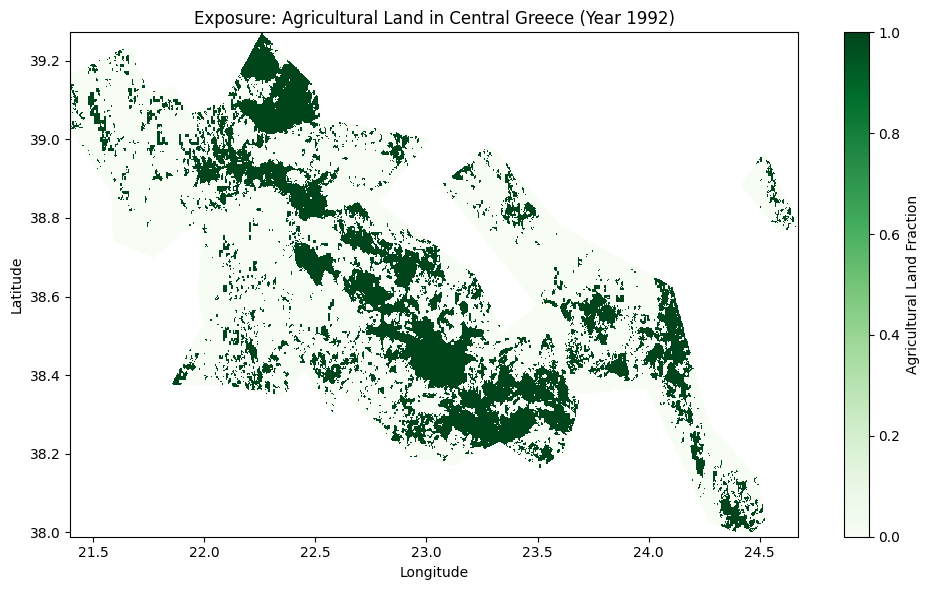

In [7]:
ag_mask = ((lc_region['lccs_class'] >= 10) & (lc_region['lccs_class'] <= 40)).astype(float)
exposure = ag_mask.where(lc_admin_mask == 1, drop=True)
fig, ax = plt.subplots(figsize=(10, 6))
exposure.plot(ax=ax, cmap='Greens', cbar_kwargs={'label': 'Agricultural Land Fraction'})
ax.set_title(f'Exposure: Agricultural Land in Central Greece (Year 1992)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Read annual land cover maps and estimate agricultural land fraction

In [10]:
# Initialize list to store results
ag_data = []

for yyyy in range(1992, 2023):  # Updated to full range

    # Inspect one zip file and read the NetCDF file to get a grid for masking
    with zipfile.ZipFile(data_dir / f'land_cover_{admin_id}_{yyyy}.zip', 'r') as zip_ref:
            
        # List all files in the zip
        file_list = zip_ref.namelist()
        print(f"Files in land_cover_{admin_id}_{yyyy}.zip")
        for f in file_list:
            print(f"  - {f}")
            
        # Find the NetCDF file (typically the largest or with .nc extension)
        nc_files_in_zip = [f for f in file_list if f.endswith('.nc')]
            
        if nc_files_in_zip:
            lc_filename = nc_files_in_zip[0]
            # Extract only this file
            zip_ref.extract(lc_filename, data_dir)
        else:
            print("No NetCDF file found in zip!")

        # Load land cover data
        lc_file = data_dir / lc_filename
        print(f"Using file: {lc_file.name}")
        lc_ds = xr.open_dataset(lc_file)

        # Subset to our region (initial bounding box)
        lc_region = lc_ds.sel(
            lon=slice(lon_min, lon_max),
            lat=slice(lat_max, lat_min)
        )

        # Create agricultural land mask: 1 where agricultural land, 0 elsewhere
        ag_mask = ((lc_region['lccs_class'] >= 10) & (lc_region['lccs_class'] <= 40)).astype(float)

        # Calculate agricultural land fraction: sum(ag_mask * admin_mask) / sum(admin_mask)
        ag_fraction = (ag_mask * lc_admin_mask).sum().values / lc_admin_mask.sum().values

        print(f"Agricultural land coverage in {admin_id} ({yyyy}): {ag_fraction*100:.1f}%")
        
        # Store result
        ag_data.append({'year': yyyy, 'ag_fraction': ag_fraction})

# Create pandas DataFrame and save to CSV
ag_timeseries = pd.DataFrame(ag_data)
ag_timeseries.set_index('year', inplace=True)

# Create output directory for satellite land cover data
output_dir = data_dir / admin_id / 'satellite_land_cover'
output_dir.mkdir(parents=True, exist_ok=True)

# Save to CSV
output_file = output_dir / f'agricultural_land_fraction_{admin_id}.csv'
ag_timeseries.to_csv(output_file)
print(f"\nTimeseries saved to: {output_file}")
print(ag_timeseries)

Files in land_cover_EL64_1992.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Agricultural land coverage in EL64 (1992): 30.5%
Files in land_cover_EL64_1993.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1993-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1993-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Agricultural land coverage in EL64 (1993): 30.5%
Files in land_cover_EL64_1994.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1994-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1994-v2.0.7cds.area-subset.39.27219519300007.2

In [16]:
# Read the CSV data
output_dir = data_dir / admin_id / 'satellite_land_cover'
output_file = output_dir / f'agricultural_land_fraction_{admin_id}.csv'
ag_data_df = pd.read_csv(output_file)

# Display the data
print("Agricultural Land Fraction Timeseries:")
print(ag_data_df)
print(f"\nSummary statistics:")
print(ag_data_df['ag_fraction'].describe())

Agricultural Land Fraction Timeseries:
    year  ag_fraction
0   1992     0.304581
1   1993     0.304572
2   1994     0.304567
3   1995     0.301157
4   1996     0.298070
5   1997     0.296245
6   1998     0.293946
7   1999     0.287148
8   2000     0.284567
9   2001     0.283580
10  2002     0.283093
11  2003     0.282551
12  2004     0.282000
13  2005     0.281638
14  2006     0.281384
15  2007     0.281008
16  2008     0.279372
17  2009     0.279048
18  2010     0.278890
19  2011     0.278649
20  2012     0.278548
21  2013     0.278506
22  2014     0.278265
23  2015     0.278200
24  2016     0.277964
25  2017     0.277709
26  2018     0.277560
27  2019     0.277074
28  2020     0.276944
29  2021     0.277014
30  2022     0.276912

Summary statistics:
count    31.000000
mean      0.284541
std       0.009277
min       0.276912
25%       0.278232
50%       0.281008
75%       0.285858
max       0.304581
Name: ag_fraction, dtype: float64


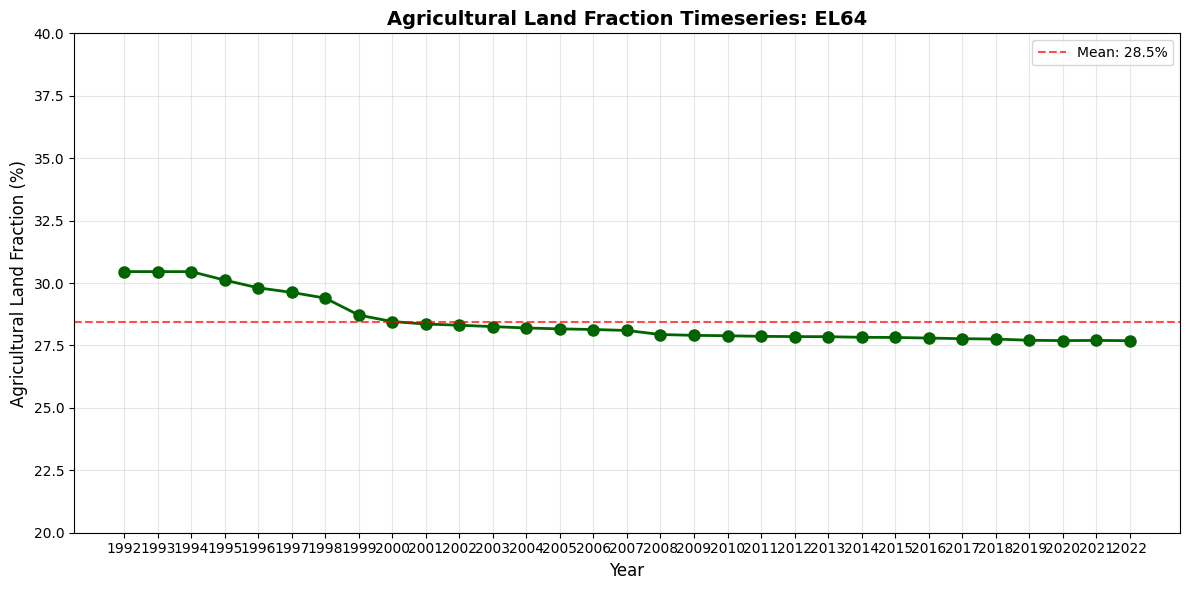


Interpretation:
- Mean agricultural land fraction: 28.5%
- Range: 27.7% to 30.5%
- Change from 1992 to 2022: -2.77 percentage points


In [15]:
# Visualize the agricultural land fraction over time
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the timeseries
ax.plot(ag_data_df['year'], ag_data_df['ag_fraction'] * 100, 
        marker='o', linewidth=2, markersize=8, color='darkgreen')

ax.set_title(f'Agricultural Land Fraction Timeseries: {admin_id}', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Agricultural Land Fraction (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=20, top=40)

# Set x-axis to show only full years
ax.set_xticks(ag_data_df['year'].values)
ax.set_xticklabels(ag_data_df['year'].values.astype(int))

# Add mean line
mean_fraction = ag_data_df['ag_fraction'].mean() * 100
ax.axhline(y=mean_fraction, color='red', linestyle='--', 
           label=f'Mean: {mean_fraction:.1f}%', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\nInterpretation:")
print(f"- Mean agricultural land fraction: {ag_data_df['ag_fraction'].mean()*100:.1f}%")
print(f"- Range: {ag_data_df['ag_fraction'].min()*100:.1f}% to {ag_data_df['ag_fraction'].max()*100:.1f}%")
change = (ag_data_df['ag_fraction'].iloc[-1] - ag_data_df['ag_fraction'].iloc[0]) * 100
print(f"- Change from {ag_data_df['year'].iloc[0]} to {ag_data_df['year'].iloc[-1]}: {change:+.2f} percentage points")

... and just like that, we have a timeseries that shows the percentage of agricultural land in your region of interest. 

## What's next? 
**Do uou want to see this data in action?** 

We use it in the "quick start" guide as exposure and to estimate drought risk! Take a look: 
- [Get started tutorial](../tutorials/get_started.ipynb)